# Session 4: Evaluating LLM Survey Simulations and Prediction-Powered Inference

We compare the simulated answers from session 2 with the human GSS answers at four levels:

1. individual-level accuracy,
2. population and subpopulation alignment,
3. the relationship between the two survey questions, and
4. prediction-powered inference (PPI).

## Installation

In [1]:
!pip install uv
!uv pip install pandas scipy numpy datasets seaborn scikit-learn ppi_python

Using Python 3.12.13 environment at: /usr
Checked 7 packages in 139ms


## Setup

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset
from ppi_py import classical_ols_ci, ppi_ols_ci, ppi_ols_pointestimate
import seaborn as sns
from scipy.stats import wasserstein_distance
from sklearn.metrics import f1_score

sns.set_theme(style="whitegrid")

We setup the variables we need for the notebook.

In [3]:
HF_REPO = "dess-mannheim/ic2s2_tutorial"
RESULT_DIR = f"hf://datasets/{HF_REPO}/inference_results/Qwen3.5-27B"

METHODS = ["reasoning", "verbalized", "sequential", "battery"] #judge_likert
SAMPLED_METHODS = ["verbalized", "sequential", "battery"]
SAMPLING_SEED = 42
METHOD_LABELS = {
    #"judge_likert": "LLM judge",
    "reasoning": "Reasoning",
    "verbalized": "Verbalized",
    "sequential": "Sequential",
    "battery": "Battery",
}

METHOD_COLORS = {
    "Human": "#222222",
    #"judge_likert": "#0173B2",
    "reasoning": "#DE8F05",
    "verbalized": "#029E73",
    "sequential": "#D55E00",
    "battery": "#CC78BC",
    "PPI": "#56B4E9",
}

QUESTIONS = {
    "gss_182": "Role of government",
    "gss_379": "Desired immigration level",
}
ANSWER_LABELS = {
    "gss_182": [
        "Government\nshould do more", "2", "3", "4",
        "Government does\ntoo much",
    ],
    "gss_379": [
        "Increased\na lot", "Increased\na little", "Remain\nthe same",
        "Reduced\na little", "Reduced\na lot",
    ],
}
SCALE = [1, 2, 3, 4, 5]
MIN_GROUP_SIZE = 30

Pick which question and which method you want to analyze for PPI.

In [4]:
# Change this to analyze another question in the subgroup plots.
SUBGROUP_QUESTION = "gss_379"
if SUBGROUP_QUESTION not in QUESTIONS:
    raise ValueError(
        f"SUBGROUP_QUESTION must be one of {list(QUESTIONS)}; "
        f"got {SUBGROUP_QUESTION!r}."
    )

# Change this to compare PPI with another simulation method.
PPI_METHOD = "sequential"
if PPI_METHOD not in METHODS:
    raise ValueError(f"PPI_METHOD must be one of {METHODS}; got {PPI_METHOD!r}.")

## Load and merge the data

We first load all of the different predictions from session 2. For verbalized,
sequential, and battery prompting, we normalize the reported probabilities and
draw one reproducible answer per respondent. Then we merge the predictions with
each individual human answer.

### Load precomputed predictions

In [5]:
results = {
    method: load_dataset(
        "csv", data_files=f"{RESULT_DIR}/result_{method}_3310.csv", split="train"
    ).to_pandas()
    for method in METHODS
}


# For the verbalized samples we could either take the argmax or sample once for each respondent
# We use sampling here and exlude non valid results
rng = np.random.default_rng(SAMPLING_SEED)
prediction_tables = []
for method, result in results.items():
    if method in SAMPLED_METHODS:
        probabilities = result.drop(
            columns=["questionnaire_name", "questionnaire_item_id", "question"]
        ).astype(float)

        def sample_answer(row):
            values = row.dropna().to_numpy(dtype=float)
            valid = (
                len(values) == len(SCALE)
                and np.isfinite(values).all()
                and (values >= 0).all()
                and (values <= 1).all()
                and values.sum() > 0
            )
            if not valid:
                return np.nan
            return rng.choice(SCALE, p=values / values.sum())

        result["prediction"] = probabilities.apply(sample_answer, axis=1)
    else:
        result["prediction"] = pd.to_numeric(
            result["answer"].astype(str).str.extract(r"^\s*([1-5])")[0]
        )
    prediction_tables.append(result.assign(method=method))

predictions = pd.concat(prediction_tables, ignore_index=True)

### Load Human Data

We compare our synthethic data against the GSS Release 2, which can be found and downloaded here: https://doi.org/10.17605/OSF.IO/M6K2J

In [6]:
# 2024 GSS Release 2, archived by ARDA: https://doi.org/10.17605/OSF.IO/M6K2J
human = pd.read_stata(
    "https://osf.io/download/h2pv9/",
    columns=["id", "helpnot", "LETIN1A"],
    convert_categoricals=False,
).rename(columns={"id": "gss_0", "helpnot": "gss_182", "LETIN1A": "gss_379"})

human["gss_0"] = "gss_p_" + human["gss_0"].astype(str)
human = (
    human.melt("gss_0", var_name="questionnaire_item_id", value_name="human")
    .rename(columns={"gss_0": "questionnaire_name"})
)
human["human"] = human["human"].where(human["human"].between(1, 5))

# Pick subgroups to analyze for subpopulation analysis
subgroups = load_dataset(HF_REPO, "interviews", split="train").to_pandas()[[
    "respondent_id",
    "primary_race",
    "presidential_vote_2020",
]]

We merge the human dataset with the predictions for each method and create an evaluation DataFrame.

In [7]:
# Create evaluation DataFrame with human answers and predictions in the same row
evaluation = (
    predictions.merge(human, on=["questionnaire_name", "questionnaire_item_id"])
    .merge(subgroups, left_on="questionnaire_name", right_on="respondent_id")
    .dropna(subset=["human", "prediction"])
)
evaluation[["human", "prediction"]] = evaluation[["human", "prediction"]].astype(int)
evaluation["question"] = evaluation["questionnaire_item_id"].map(QUESTIONS)
evaluation[["questionnaire_name", "method", "question", "human", "prediction"]].head()

,questionnaire_name,method,question,human,prediction
0,gss_p_1,reasoning,Role of government,3,3
1,gss_p_1,reasoning,Desired immigration level,4,2
2,gss_p_2,reasoning,Role of government,3,1
3,gss_p_2,reasoning,Desired immigration level,4,2
4,gss_p_3,reasoning,Role of government,1,1


## 1. Overall F1 score

How good can each method predict each individual response?

How much can reasonably be expected?

Is this a good measure?

In [8]:
overall_f1 = pd.DataFrame([
    {
        "method": METHOD_LABELS[method],
        "f1_score": f1_score(
            evaluation.loc[evaluation["method"] == method, "human"],
            evaluation.loc[evaluation["method"] == method, "prediction"],
            labels=SCALE, average="macro",
        ),
    }
    for method in METHODS
])
overall_f1.round(3)

,method,f1_score
0,Reasoning,0.282
1,Verbalized,0.245
2,Sequential,0.244
3,Battery,0.266


## 2. Population and subpopulation alignment

First, we compare the answer distributions produced by each method with the human distribution.

In [9]:
# Calculate distributions code
human_distribution = (
    evaluation[["questionnaire_name", "question", "human"]]
    .drop_duplicates()
    .rename(columns={"human": "answer"})
    .assign(source="Human")
)
llm_distribution = evaluation[[
    "questionnaire_name", "question", "prediction", "method"
]].rename(columns={"prediction": "answer", "method": "source"})

distribution = (
    pd.concat([human_distribution, llm_distribution], ignore_index=True)
    .groupby(["question", "source", "answer"])
    .size().rename("n").reset_index()
)
distribution["proportion"] = distribution["n"] / distribution.groupby(
    ["question", "source"]
)["n"].transform("sum")

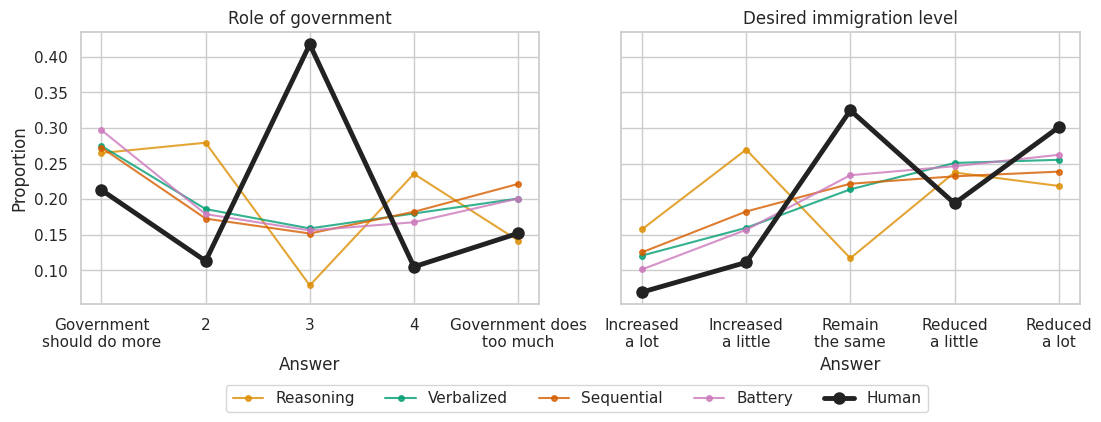

In [10]:
# Plot code
fig, axes = plt.subplots(1, len(QUESTIONS), figsize=(13, 4), sharey=True)

for ax, (key, question) in zip(axes, QUESTIONS.items()):
    question_distribution = distribution[distribution["question"] == question]
    for source in [*METHODS, "Human"]:
        values = question_distribution[question_distribution["source"] == source]
        is_human = source == "Human"
        ax.plot(
            values["answer"], values["proportion"],
            color=METHOD_COLORS[source],
            label="Human" if is_human else METHOD_LABELS[source],
            marker="o", linewidth=3.5 if is_human else 1.5,
            markersize=8 if is_human else 4, alpha=1 if is_human else 0.8,
            zorder=10 if is_human else 2,
        )
    ax.set(title=question, xlabel="Answer", xticks=SCALE)
    ax.set(xticks=SCALE, xticklabels=ANSWER_LABELS[key])

axes[0].set_ylabel("Proportion")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(labels), bbox_to_anchor = (0.45, -0.07))
fig.tight_layout(rect=[0, 0, 0.86, 1])
plt.show()

### Alignment within voter subpopulations

We now focus on one configurable question (`SUBGROUP_QUESTION`) and compare Trump and Biden voters. First, the human distributions show how the subpopulations differ, with the selected PPI method shown directly below. Then Wasserstein distance measures how closely each simulation method reproduces each human distribution; smaller values indicate better alignment.

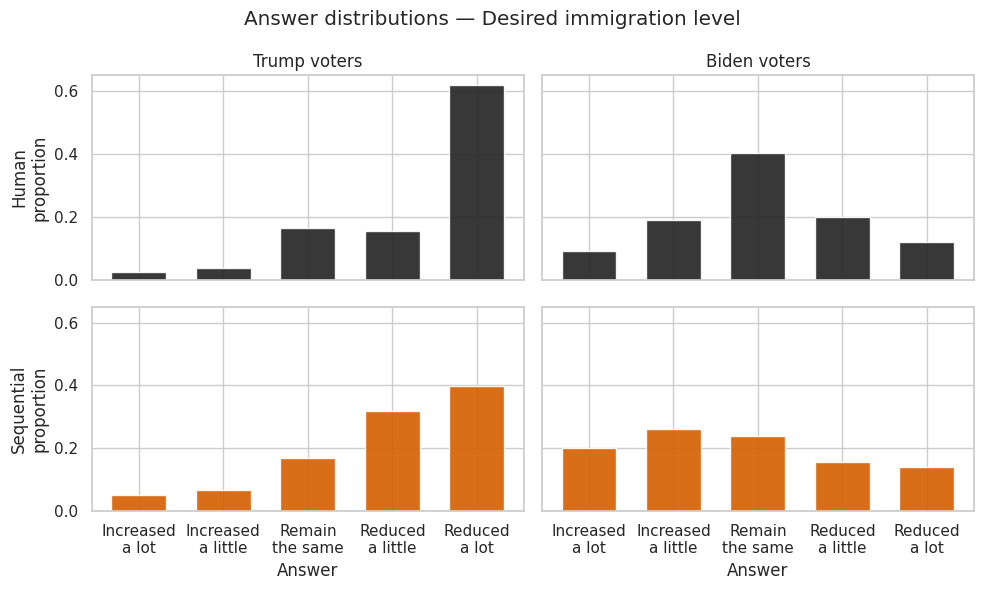

In [11]:
# subpopulation code
VOTE_COLUMN = "presidential_vote_2020"
VOTE_GROUPS = ["Trump", "Biden"]
answer_labels = ANSWER_LABELS[SUBGROUP_QUESTION]

human_vote_answers = (
    human[human["questionnaire_item_id"] == SUBGROUP_QUESTION]
    .merge(subgroups, left_on="questionnaire_name", right_on="respondent_id")
    .query(f"`{VOTE_COLUMN}` in @VOTE_GROUPS")
    .dropna(subset=["human"])
)
selected_subgroups = evaluation[
    (evaluation["questionnaire_item_id"] == SUBGROUP_QUESTION)
    & (evaluation[VOTE_COLUMN].isin(VOTE_GROUPS))
]
llm_vote_answers = selected_subgroups[
    selected_subgroups["method"] == PPI_METHOD
]


def plot_vote_distributions(axes, data, answer_column, label, color):
    for ax, group_name in zip(axes, VOTE_GROUPS):
        answers = data.loc[data[VOTE_COLUMN] == group_name, answer_column]
        proportions = (
            answers.value_counts(normalize=True).reindex(SCALE, fill_value=0)
        )
        ax.bar(
            SCALE, proportions, color=color,
            alpha=0.9, edgecolor="white", width=0.65,
        )
        ax.set(xticks=SCALE, xticklabels=answer_labels)
    axes[0].set_ylabel(f"{label}\nproportion")


fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
plot_vote_distributions(
    axes[0], human_vote_answers, "human", "Human", METHOD_COLORS["Human"]
)
plot_vote_distributions(
    axes[1], llm_vote_answers, "prediction",
    METHOD_LABELS[PPI_METHOD], METHOD_COLORS[PPI_METHOD],
)

for ax, group_name in zip(axes[0], VOTE_GROUPS):
    ax.set_title(f"{group_name} voters")
for ax in axes[1]:
    ax.set_xlabel("Answer")

fig.suptitle(f"Answer distributions — {QUESTIONS[SUBGROUP_QUESTION]}")
fig.tight_layout()
plt.show()

A common measure is Wasserstein distance.

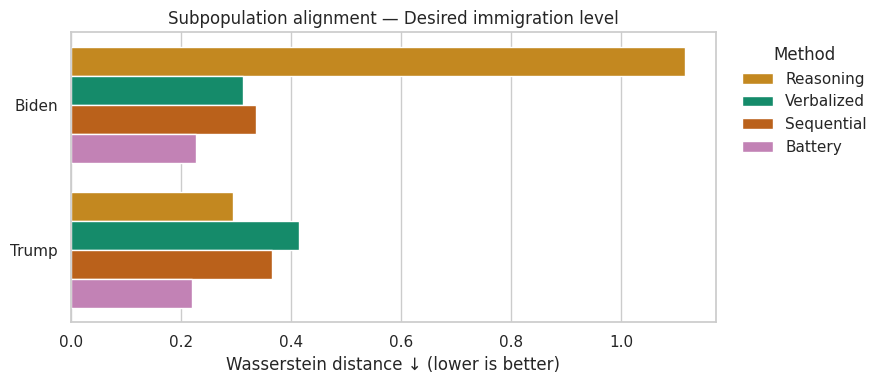

In [12]:
# Wasserstein distance
distance_rows = []
excluded_rows = []
for (method, group_name), group in selected_subgroups.groupby(
    ["method", VOTE_COLUMN]
):
    row = {"method": method, "group": group_name, "n": len(group)}
    if len(group) >= MIN_GROUP_SIZE:
        row["wasserstein"] = wasserstein_distance(
            group["human"], group["prediction"]
        )
        distance_rows.append(row)
    else:
        excluded_rows.append(row)

subgroup_distances = pd.DataFrame(distance_rows)
if subgroup_distances.empty:
    raise ValueError(
        f"No subgroup has at least MIN_GROUP_SIZE={MIN_GROUP_SIZE} valid pairs."
    )

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(
    data=subgroup_distances.assign(
        method_label=subgroup_distances["method"].map(METHOD_LABELS)
    ),
    x="wasserstein", y="group", hue="method_label",
    hue_order=[METHOD_LABELS[method] for method in METHODS],
    palette={
        METHOD_LABELS[method]: METHOD_COLORS[method] for method in METHODS
    },
    ax=ax,
)
ax.set(
    xlabel="Wasserstein distance ↓ (lower is better)",
    ylabel="",
    title=f"Subpopulation alignment — {QUESTIONS[SUBGROUP_QUESTION]}",
)
ax.legend(title="Method", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

## 3. OLS regression: Do the simulations preserve the relationship between the two questions?

Matching the two answer distributions separately does not guarantee that a method reproduces how the answers vary together. We summarize that relationship with a simple ordinary least squares model:

$$\text{Immigration answer}_i = \beta_0 + \beta_1\,\text{Government-role answer}_i + \varepsilon_i.$$

Both scales run from 1 to 5. A positive slope means that moving one point toward *government does too much* is associated with an expected shift toward *immigration should be reduced*. This is an associational description, not a causal claim. We are most interested in \beta_1, as it measures the correlation between the two answers.

In [13]:
X_QUESTION = "gss_182"
Y_QUESTION = "gss_379"


def ols_slope_ci(x, y):
    """Return beta_1 and its classical 95% confidence interval."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    design = np.column_stack([np.ones(len(x)), x])
    beta = np.linalg.lstsq(design, y, rcond=None)[0]
    ci_low, ci_high = classical_ols_ci(design, y, alpha=0.05)
    return float(beta[1]), float(ci_low[1]), float(ci_high[1])


human_wide = human.pivot(
    index="questionnaire_name", columns="questionnaire_item_id", values="human"
)[[X_QUESTION, Y_QUESTION]].dropna()

paired_answers = {"Human": human_wide}
for method, group in evaluation.groupby("method"):
    paired_answers[method] = group.pivot(
        index="questionnaire_name",
        columns="questionnaire_item_id",
        values="prediction",
    )[[X_QUESTION, Y_QUESTION]].dropna()

regression_rows = []
for source in ["Human", *METHODS]:
    paired = paired_answers[source]
    beta_1, ci_low, ci_high = ols_slope_ci(
        paired[X_QUESTION], paired[Y_QUESTION]
    )
    r_squared = np.corrcoef(
        paired[X_QUESTION], paired[Y_QUESTION]
    )[0, 1] ** 2

    regression_rows.append({
        "source": "Human" if source == "Human" else METHOD_LABELS[source],
        "n": len(paired),
        "beta_1": beta_1,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "r_squared": r_squared,
    })

regression_results = pd.DataFrame(regression_rows)
human_beta_1 = regression_results.loc[
    regression_results["source"] == "Human", "beta_1"
].iloc[0]
regression_results["abs_error"] = (
    regression_results["beta_1"] - human_beta_1
).abs()
regression_results['ci_width'] = (regression_results.ci_high - regression_results.ci_low)
true_beta_1 = regression_results[regression_results.source == 'Human'].iloc[0].beta_1
regression_results['coverage'] = (regression_results.ci_high > true_beta_1) & (regression_results.ci_low < true_beta_1)
regression_results[['source', 'r_squared', 'abs_error', 'ci_width', 'coverage']].round(3)

,source,r_squared,abs_error,ci_width,coverage
0,Human,0.111,0.000,0.078,True
1,Reasoning,0.604,0.444,0.048,False
2,Verbalized,0.017,0.196,0.077,False
3,Sequential,0.067,0.088,0.072,False
4,Battery,0.035,0.151,0.072,False


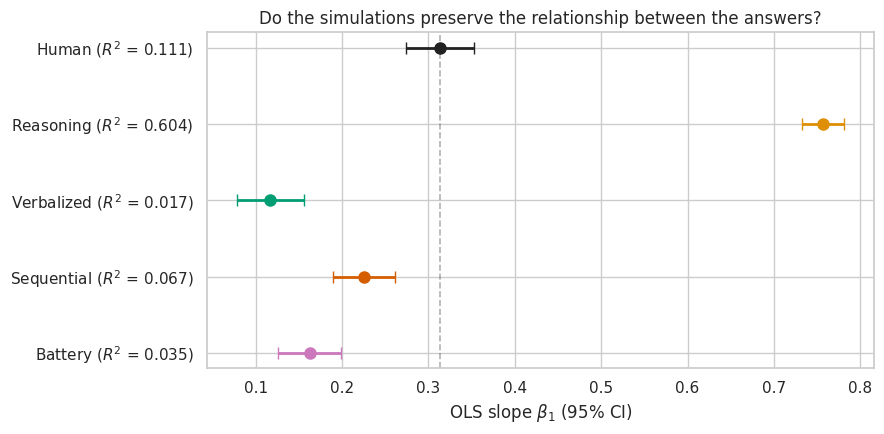

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))

source_keys = ["Human", *METHODS]
for position, (source_key, row) in enumerate(
    zip(source_keys, regression_results.itertuples(index=False))
):
    color = METHOD_COLORS[source_key]
    ax.errorbar(
        row.beta_1,
        position,
        xerr=[[row.beta_1 - row.ci_low], [row.ci_high - row.beta_1]],
        fmt="o",
        color=color,
        markersize=8,
        capsize=4,
        linewidth=2,
    )

ax.axvline(
    human_beta_1, color=METHOD_COLORS["Human"],
    linestyle="--", alpha=0.35, linewidth=1.2,
)
ax.set_yticks(range(len(regression_results)))
ax.set_yticklabels([
    f"{row.source} ($R^2$ = {row.r_squared:.3f})"
    for row in regression_results.itertuples()
])
ax.invert_yaxis()
ax.set(
    xlabel=r"OLS slope $\beta_1$ (95% CI)",
    title="Do the simulations preserve the relationship between the answers?",
)
fig.tight_layout()
plt.show()

LLM Judge and Reasoning overestimate the relation between the question, the verbalized method slightly underestimate it.

# 4. Prediction-Powered Inference for the OLS

We now estimate the same relationship,

$$\text{Immigration answer}_i =
\beta_0 + \beta_1\,\text{Government-role answer}_i + \varepsilon_i,$$

with only a small labeled human answers sample. The human government-role answer is treated
as an observed covariate \(X\) for every respondent. The selected simulation
method predicts the immigration outcome \(\hat Y\).

In [15]:
N_LABELED = 100
RANDOM_SEED = 1

predicted_immigration = (
    evaluation[
        (evaluation["method"] == PPI_METHOD)
        & (evaluation["questionnaire_item_id"] == Y_QUESTION)
    ][["questionnaire_name", "prediction"]]
    .drop_duplicates(subset="questionnaire_name")
    .set_index("questionnaire_name")
    .rename(columns={"prediction": "llm_y"})
)

ppi_df = (
    human_wide.rename(
        columns={X_QUESTION: "observed_x", Y_QUESTION: "human_y"}
    )
    .join(predicted_immigration, how="inner")
    .dropna()
)

print(
    f"Regression: {QUESTIONS[Y_QUESTION]} on {QUESTIONS[X_QUESTION]} | "
    f"method: {METHOD_LABELS[PPI_METHOD]} | n = {len(ppi_df)}"
)

Regression: Desired immigration level on Role of government | method: Sequential | n = 2042


## Step 1 — Ground truth: all human answers

Because we have access to all human answers we can calculate the regression on the full dataset to estimate a "ground truth".

In [16]:
truth_beta_1, truth_low, truth_high = ols_slope_ci(
    ppi_df["observed_x"], ppi_df["human_y"]
)
print(
    f"Full-human beta_1: {truth_beta_1:.3f} "
    f"(95% CI [{truth_low:.3f}, {truth_high:.3f}])"
)

Full-human beta_1: 0.313 (95% CI [0.274, 0.352])


## Step 2 — LLM outcome-only regression

Let's run the same regression on the full simulated answers to compare.

In [17]:
llm_beta_1, llm_low, llm_high = ols_slope_ci(
    ppi_df["observed_x"], ppi_df["llm_y"]
)
print(
    f"LLM-outcome-only beta_1: {llm_beta_1:.3f} "
    f"(difference from full-human beta_1 = {llm_beta_1 - truth_beta_1:+.3f})"
)

LLM-outcome-only beta_1: 0.143 (difference from full-human beta_1 = -0.170)


## Step 3 — Prediction-powered OLS

PPI uses:
- A small **labeled set** (`N_LABELED` respondents): we have *both* a human answer and an LLM prediction
- A large **unlabeled set**: we only have LLM predictions

It corrects the LLM's bias using the labeled set and produces a statistically valid CI.

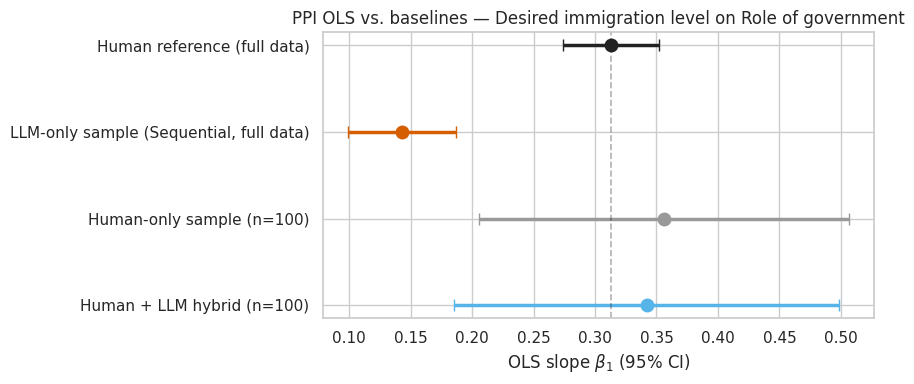

Labeled n = 100, Unlabeled N = 1942


,estimator,abs_error,ci_width,coverage
1,"LLM-only sample (Sequential, full data)",0.170,0.088,False
2,Human-only sample (n=100),0.043,0.301,True
3,Human + LLM hybrid (n=100),0.029,0.313,True


In [18]:
rng = np.random.default_rng(RANDOM_SEED)
indices = rng.permutation(len(ppi_df))
labeled = ppi_df.iloc[indices[:N_LABELED]]
unlabeled = ppi_df.iloc[indices[N_LABELED:]]

X_labeled = np.column_stack([
    np.ones(len(labeled)), labeled["observed_x"].to_numpy(dtype=float)
])
X_unlabeled = np.column_stack([
    np.ones(len(unlabeled)), unlabeled["observed_x"].to_numpy(dtype=float)
])
Y = labeled["human_y"].to_numpy(dtype=float)
Y_hat = labeled["llm_y"].to_numpy(dtype=float)
Y_hat_unlabeled = unlabeled["llm_y"].to_numpy(dtype=float)

labeled_beta_1, labeled_low, labeled_high = ols_slope_ci(
    labeled["observed_x"], labeled["human_y"]
)
ppi_beta = ppi_ols_pointestimate(
    X_labeled, Y, Y_hat, X_unlabeled, Y_hat_unlabeled
)
ppi_low, ppi_high = ppi_ols_ci(
    X_labeled, Y, Y_hat, X_unlabeled, Y_hat_unlabeled, alpha=0.05
)

ppi_results = pd.DataFrame([
    {
        "estimator": "Human reference (full data)",
        "beta_1": truth_beta_1, "ci_low": truth_low, "ci_high": truth_high,
    },
    {
        "estimator": f"LLM-only sample ({METHOD_LABELS[PPI_METHOD]}, full data)",
        "beta_1": llm_beta_1, "ci_low": llm_low, "ci_high": llm_high,
    },
    {
        "estimator": f"Human-only sample (n={N_LABELED})",
        "beta_1": labeled_beta_1,
        "ci_low": labeled_low, "ci_high": labeled_high,
    },
    {
        "estimator": f"Human + LLM hybrid (n={N_LABELED})",
        "beta_1": float(ppi_beta[1]),
        "ci_low": float(ppi_low[1]), "ci_high": float(ppi_high[1]),
    },
])

colors = [
    METHOD_COLORS["Human"],
    METHOD_COLORS[PPI_METHOD],
    "#999999",
    METHOD_COLORS["PPI"],
]
fig, ax = plt.subplots(figsize=(9, 4))
for position, (row, color) in enumerate(
    zip(ppi_results.itertuples(index=False), colors)
):
    ax.errorbar(
        row.beta_1,
        position,
        xerr=[[row.beta_1 - row.ci_low], [row.ci_high - row.beta_1]],
        fmt="o",
        color=color,
        markersize=9,
        capsize=4,
        linewidth=2.5,
    )

ax.axvline(
    truth_beta_1, color=METHOD_COLORS["Human"],
    linestyle="--", alpha=0.35, linewidth=1.2,
)
ax.set_yticks(range(len(ppi_results)))
ax.set_yticklabels(ppi_results["estimator"])
ax.invert_yaxis()
ax.set(
    xlabel=r"OLS slope $\beta_1$ (95% CI)",
    title=(
        f"PPI OLS vs. baselines — "
        f"{QUESTIONS[Y_QUESTION]} on {QUESTIONS[X_QUESTION]}"
    ),
)
fig.tight_layout()
plt.show()

print(f"Labeled n = {len(labeled)}, Unlabeled N = {len(unlabeled)}")

ppi_results['abs_error'] = (truth_beta_1 - ppi_results.beta_1).abs()
ppi_results['ci_width'] = (ppi_results.ci_high - ppi_results.ci_low)
ppi_results['coverage'] = (ppi_results.ci_high > truth_beta_1) & (ppi_results.ci_low < truth_beta_1)
ppi_results.iloc[1:][['estimator', 'abs_error', 'ci_width', 'coverage']].round(3)